In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/datasets/Train_amazon.csv')

In [5]:
df.head(10)

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0
5,5942,User5942,NaN,Non-Binary,NaN,Bottom,Social Media,Evening,1
6,7808,User7808,26.0,Female,Desktop,Top,NaN,NaN,1
7,5065,User5065,40.0,Male,Mobile,Side,NaN,Evening,0
8,7993,User7993,NaN,Non-Binary,Mobile,Bottom,Social Media,NaN,1
9,4509,User4509,NaN,NaN,NaN,Bottom,Education,Afternoon,1


In [5]:
df.shape

(9000, 9)

In [6]:
# Data preprocessing
    # data cleaning:
    # 1. Null values

df.isnull().sum()

,0
id,0
full_name,0
age,4288
gender,4212
device_type,1802
ad_position,1810
browsing_history,4295
time_of_day,1808
click,0


In [7]:
# since null values are > 10% of data, we need to impute them
# 2. Handling null values

val = df['age'].mean()
val = val.astype(int)
val

np.int64(40)

In [8]:
# a. imputing age with mean
df['age'].fillna(val, inplace = True)

In [9]:
# b. imputing gender with mode
fill_val =df['gender'].mode()[0]
df['gender'].fillna(fill_val, inplace = True)

In [10]:
# c. imputing device_type with mode
df['device_type'].fillna(df['device_type'].mode()[0], inplace = True)

In [11]:
# d. imputing ad_position with mode
df['ad_position'].fillna(df['ad_position'].mode()[0], inplace=True)

In [12]:
# e. Browsing history with mode
df['browsing_history'].fillna(df['browsing_history'].mode()[0], inplace=True)

In [13]:
df['time_of_day'].fillna(df['time_of_day'].mode()[0], inplace = True)

In [14]:
df.isnull().sum()

,0
id,0
full_name,0
age,0
gender,0
device_type,0
ad_position,0
browsing_history,0
time_of_day,0
click,0


# checking for outliers:

In [17]:
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3-q1
l_l = q1 -1.5*iqr
u_l = q3 +1.5*iqr


In [ ]:
outliers = df[(df['age']< l_l) | (df['age']> u_l)]
(len(outliers)/ len(df)) *100

# we can't remove 41% of the age column


41.18888888888889

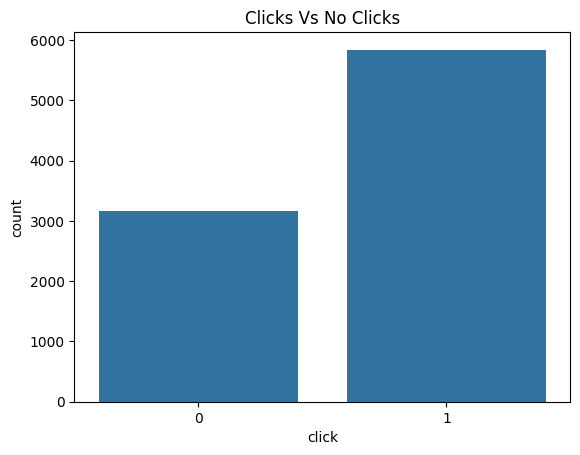

In [ ]:
sns.countplot(x = df [ 'click'])
plt.title('Clicks Vs No Clicks')
plt.show()

# In general do people click ads displayed on the website?

In [15]:
overall_ctr = df['click'].mean()
print(f'Overall CTR: {overall_ctr:.2%}')


Overall CTR: 64.88%


Text(0.5, 1.0, 'Click Rate by Age Group')

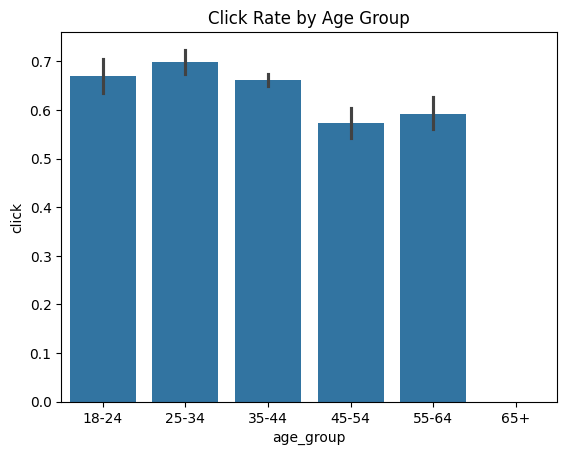

In [18]:
df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 45, 55, 65, 100],
                         labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])

sns.barplot(x=df['age_group'], y=df['click'])
plt.title("Click Rate by Age Group")

# which age group was more likely to click the ads?

Text(0.5, 1.0, 'Browsing Category and Click Behavior')

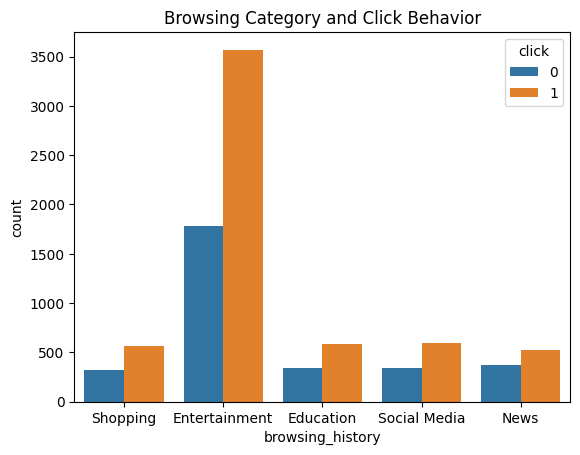

In [ ]:
sns.countplot(x=df['browsing_history'], hue=df['click'])
plt.title("Browsing Category and Click Behavior")

# what type of ads were clicked?


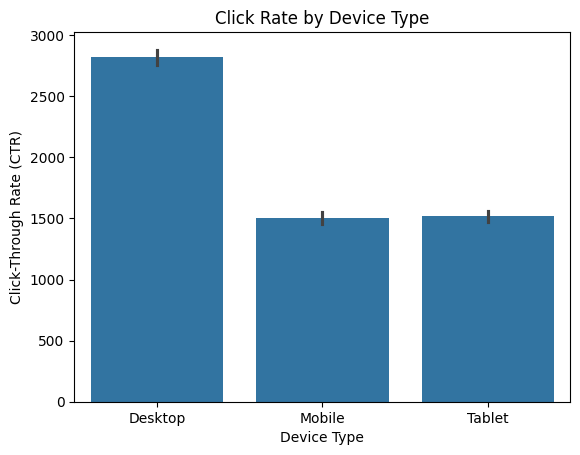

In [ ]:
sns.barplot(x=df['device_type'], y=df['click'], estimator=lambda x: x.mean())
plt.ylabel('Click-Through Rate (CTR)')
plt.xlabel('Device Type')
plt.title('Click Rate by Device Type')
plt.show()

# Which device types generate the highest click-through rates?

In [29]:
df.groupby('device_type')['click'].mean()

,click
device_type,
Desktop,0.655277
Mobile,0.637521
Tablet,0.648164


// Does user engagement (CTR) vary across different devices?

yes, Users were more likely to click on ads when they used desktop

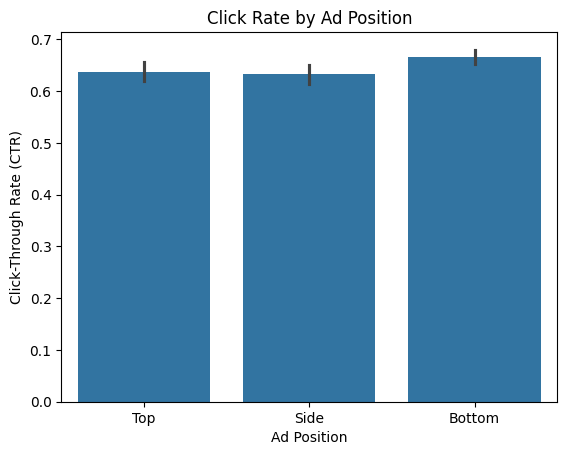

In [ ]:
sns.barplot(x=df['ad_position'], y=df['click'], estimator = lambda x:x.mean())
plt.ylabel('Click-Through Rate (CTR)')
plt.xlabel('Ad Position')
plt.title('Click Rate by Ad Position')
plt.show()

# Which ad positions lead to the highest user engagement?

# it seems the ads positioned at the bottom had slightly more clicks than the other 2

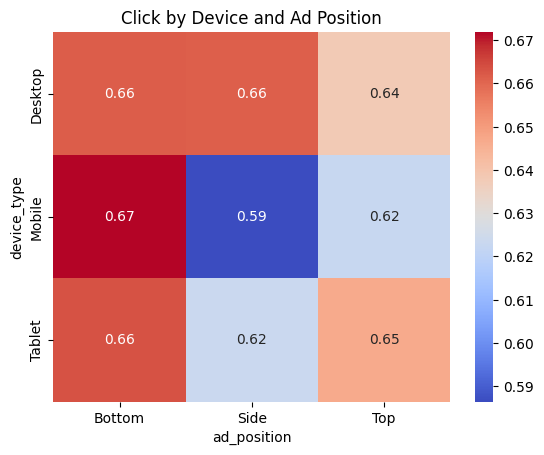

In [ ]:
pivot = df.pivot_table( index = 'device_type', columns = 'ad_position', values = 'click', aggfunc = 'mean')
sns.heatmap(pivot, annot = True,cmap = 'coolwarm')
plt.title('Click by Device and Ad Position')
plt.show()

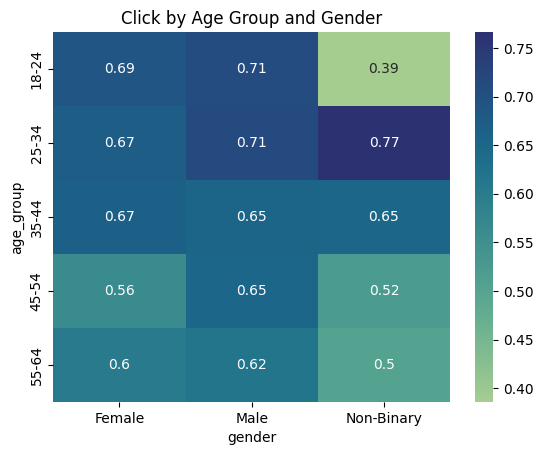

In [23]:
# CTR by Age Group,Gender

pivot1 = df.pivot_table(index = 'age_group', columns = 'gender', values = 'click', aggfunc = 'mean')
sns.heatmap(pivot1, annot = True, cmap = 'crest')
plt.title('Click by Age Group and Gender')
plt.show()

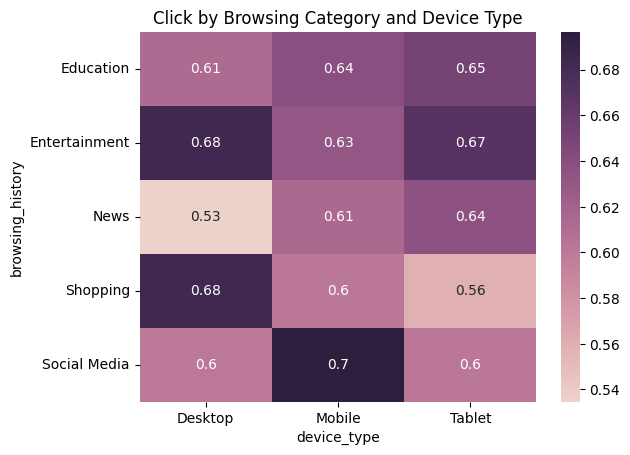

In [24]:
# CTR by Browsing Category ,Device Type

pivot2 =df.pivot_table(index = 'browsing_history',columns = 'device_type',values = 'click', aggfunc = 'mean')
sns.heatmap(pivot2, annot = True, cmap = sns.cubehelix_palette(as_cmap=True))
plt.title('Click by Browsing Category and Device Type')
plt.show()

In [17]:
print(" Summary of Findings and Business Insights:\n")

# 1. Overall CTR
print(f"1. Overall Click-Through Rate (CTR): {overall_ctr:.2%}")

# 2. Device Type
print("2. Device Type:")
print("\t- Desktop users have the highest CTR: 65.53%")
print("\t- Mobile and Tablet users show slightly lower CTRs: 63.75% and 64.82%, respectively")
print("\t Insight: Focus on optimizing desktop ad experience, especially for high-intent users.")

# 3. Ad Position
print("3. Ad Position:")
print("\t- Ads shown at the 'Bottom' position had slightly higher CTR.")
print("\t- 'Top' and 'Middle' positions performed less effectively.")
print("\t Insight: Test more bottom-position placements or reevaluate underperforming slots.")

# 4. Device + Position Interaction
print("4. Heatmap (Device × Ad Position):")
print("\t- High CTRs were observed across all devices when ads were placed at the bottom.")
print("\t Insight: Reinforce ad placement strategies focusing on device-specific bottom-position ads.")

# 5. Age Group
print("5. Age Group:")
print("\t- Users aged 18–24 and 25–34 show the highest CTRs.")
print("\t- Lower engagement observed from users aged 45–54.")
print("\t Insight: Prioritize targeting the 18–44 demographic with relevant creatives.")

# 6. Browsing History
print("6. Browsing History:")
print("\t- Entertainment category led with the highest CTR.")
print("\t- Other categories showed relatively even performance.")
print("\t Insight: Segment users by interest category and personalize content for better performance.")

# 7. Heatmap - Category × Device
print("7.  Category + Device Heatmap:")
print("\t- Entertainment and shopping ads performed best on Desktop (~68%).")
print("\t- Social Media ads saw highest CTR (~70%) on Mobile.")
print("\t- Education ads performed best on Tablets.")
print("\t Insight: Match ad category to device platform where they perform best.")


 Summary of Findings and Business Insights:

1. Overall Click-Through Rate (CTR): 64.88%
2. Device Type:
	- Desktop users have the highest CTR: 65.53%
	- Mobile and Tablet users show slightly lower CTRs: 63.75% and 64.82%, respectively
	 Insight: Focus on optimizing desktop ad experience, especially for high-intent users.
3. Ad Position:
	- Ads shown at the 'Bottom' position had slightly higher CTR.
	- 'Top' and 'Middle' positions performed less effectively.
	 Insight: Test more bottom-position placements or reevaluate underperforming slots.
4. Heatmap (Device × Ad Position):
	- High CTRs were observed across all devices when ads were placed at the bottom.
	 Insight: Reinforce ad placement strategies focusing on device-specific bottom-position ads.
5. Age Group:
	- Users aged 18–24 and 25–34 show the highest CTRs.
	- Lower engagement observed from users aged 45–54.
	 Insight: Prioritize targeting the 18–44 demographic with relevant creatives.
6. Browsing History:
	- Entertainment categ